# 🧬 BioSLATE Project — Phase 1, Step 1: TCGA Biomarker Discovery

**Author:** Faith Ogundimu  
**Date:** June 2025  
**Notebook Purpose:**  
This notebook analyses copy number alteration (CNA) and proteomic data from The Cancer Genome Atlas (TCGA) to identify potential biomarkers in High-Grade Serous Ovarian Cancer (HGSOC).  
Genes amplified or deleted in ≥5% of TCGA patients are evaluated for functional relevance by comparing copy number levels to protein expression. Significant alterations are prioritised based on statistical significance and biological effect size.

---

> **Context:** This is the first step of the BioSLATE biomarker pipeline.  
> Results from this notebook are cross-validated in Step 2 using experimental data from HGSOC cell lines in the DepMap resource.

## Step 1: TCGA and PanCancer Dataset Preprocessing
Take the PanCancer dataset and filter to only keep the +2 _(Amplifications (AMP))_ and the -2 _(Homozygous Deletions (HOMDEL))_

### Download Necessary Files
Dataset Links:   
https://www.cbioportal.org/study/summary?id=ov_tcga_pan_can_atlas_2018 - CNV and Proteomics Info 

In [2]:
#Unzip gzipped files
!gunzip /Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/ov_tcga_pan_can_atlas_2018.tar.gz

In [4]:
#Extract tar file.
!tar -xvf /Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/ov_tcga_pan_can_atlas_2018.tar -C /Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/

x ov_tcga_pan_can_atlas_2018/
x ov_tcga_pan_can_atlas_2018/meta_resource_definition.txt
x ov_tcga_pan_can_atlas_2018/data_log2_cna.txt


x ov_tcga_pan_can_atlas_2018/meta_timeline_treatment.txt
x ov_tcga_pan_can_atlas_2018/data_clinical_supp_hypoxia.txt
x ov_tcga_pan_can_atlas_2018/meta_resource_patient.txt
x ov_tcga_pan_can_atlas_2018/data_clinical_sample.txt
x ov_tcga_pan_can_atlas_2018/data_phosphoprotein_quantification.txt
x ov_tcga_pan_can_atlas_2018/meta_study.txt
x ov_tcga_pan_can_atlas_2018/meta_mrna_seq_v2_rsem.txt
x ov_tcga_pan_can_atlas_2018/LICENSE
x ov_tcga_pan_can_atlas_2018/data_timeline_status.txt
x ov_tcga_pan_can_atlas_2018/data_resource_patient.txt
x ov_tcga_pan_can_atlas_2018/data_genetic_ancestry.txt
x ov_tcga_pan_can_atlas_2018/meta_genetic_ancestry.txt
x ov_tcga_pan_can_atlas_2018/meta_armlevel_cna.txt
x ov_tcga_pan_can_atlas_2018/data_timeline_treatment.txt
x ov_tcga_pan_can_atlas_2018/data_methylation_hm27_hm450_merged.txt
x ov_tcga_pan_can_atlas_2018/data_armlevel_cna.txt
x ov_tcga_pan_can_atlas_2018/meta_clinical_patient.txt
x ov_tcga_pan_can_atlas_2018/meta_log2_cna.txt
x ov_tcga_pan_can_atl

### 🧬 What is a GISTIC Score?

**GISTIC** (Genomic Identification of Significant Targets in Cancer) is a method used to identify regions of the genome that are **significantly amplified or deleted** across a set of cancer samples.

Each **GISTIC score** represents the **copy number status of a gene** in a given sample:

| GISTIC Score | Interpretation                  |
| ------------ | ------------------------------- |
| **-2**       | Deep (homozygous) deletion      |
| **-1**       | Shallow (heterozygous) deletion |
| **0**        | Diploid (normal copy number)    |
| **+1**       | Low-level gain                  |
| **+2**       | High-level amplification        |

These scores help identify **copy number alterations (CNAs)** that may drive cancer progression or serve as **therapeutic targets or biomarkers**.


In [114]:
import pandas as pd

# Load the file with tab as delimiter, keep Entrez IDs as strings initially
cna_df = pd.read_csv(
    "/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/cBioPortal/ov_tcga_pan_can_atlas_2018/data_cna.txt", 
    sep='\t',
    dtype={"Entrez_Gene_Id": "string"}  # keeps as string, no decimals
)

# Drop rows where Entrez_Gene_Id is missing or empty
cna_df = cna_df[cna_df["Entrez_Gene_Id"].notna() & (cna_df["Entrez_Gene_Id"] != "")]

# Set Entrez_Gene_Id as index
cna_df.set_index("Entrez_Gene_Id", inplace=True)

# Drop Hugo_Symbol column
cna_df.drop(columns=["Hugo_Symbol"], inplace=True)

cna_df.head()

,TCGA-04-1331-01,TCGA-04-1332-01,TCGA-04-1335-01,TCGA-04-1336-01,TCGA-04-1337-01,TCGA-04-1338-01,TCGA-04-1341-01,TCGA-04-1342-01,TCGA-04-1343-01,TCGA-04-1346-01,...,TCGA-72-4235-01,TCGA-72-4236-01,TCGA-72-4237-01,TCGA-72-4238-01,TCGA-72-4240-01,TCGA-72-4241-01,TCGA-OY-A56P-01,TCGA-OY-A56Q-01,TCGA-VG-A8LO-01,TCGA-WR-A838-01
Entrez_Gene_Id,,,,,,,,,,,,,,,,,,,,,
116983,-1,0,-1,1,0,-1,-1,0,1,-1,...,0,0,2,0,0,1,1,0,1,-1
140625,-1,0,-1,1,0,-1,-1,0,1,-1,...,0,0,2,0,0,1,1,0,1,-1
375790,-1,0,-1,1,0,-1,-1,0,1,-1,...,0,0,2,0,0,1,1,0,1,-1
441869,-1,0,-1,1,0,-1,-1,0,1,-1,...,0,0,2,0,0,1,1,0,1,-1
55210,-1,0,-1,1,0,-1,-1,0,1,-1,...,0,0,2,0,0,1,1,0,1,-1


### 🔍 Why Copy Number Variations (CNVs) Are Difficult to Interpret in Cancer Data
> Copy number variations (CNVs) such as deletions or amplifications can be challenging to interpret accurately in tumour samples due to the heterogeneous nature of cancer tissue. A tumour biopsy typically contains a mixture of both cancerous and normal (non-cancerous) cells. Because of this, CNV estimates (like those from GISTIC analyses) represent an average signal across the entire cell population, not just the tumour cells.

> For example, a GISTIC score of -2 or +2 may indicate a strong deletion or amplification, respectively, but it doesn’t necessarily mean that every cell in the sample carries that alteration. Instead, it reflects what is observed on average. If the tumour purity is low (i.e., many normal cells are present), even a biologically significant CNV may appear less extreme.

> This tumour heterogeneity introduces noise and uncertainty in CNV interpretation, which researchers must consider when linking copy number events to gene dependencies or therapeutic vulnerabilities.

In [115]:
# Export to CSV
cna_df.to_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/full_cna_tcga.csv")

In [116]:
cna_df.shape
# 24,959 genes, 572 samples.

(24959, 572)

In [117]:
# Count how many cell lines have +2 or -2 per gene (i.e. per the index)
amplified_counts = (cna_df == 2).sum(axis=1)
deleted_counts = (cna_df == -2).sum(axis=1)
# axis = 1 is the columns (i.e. what we want)

# Keep genes amplified or deleted in ≥5% patient samples.
threshold = int(len(cna_df.columns) * 0.05) # good to keep it as a variable first to prevent long legnths of code.
# use int to ensure that it rounds up and remains a non-decimal (float) number.

amp_genes = amplified_counts[amplified_counts >= threshold].index
del_genes = deleted_counts[deleted_counts >= threshold].index

# Final candidate genes = union of both
candidate_genes = amp_genes.union(del_genes)

In [118]:
amp_genes

# Length = 3334 genes

Index(['81493', '57648', '79932', '5690', '127703', '63967', '192670', '26523',
       '192669', '27285',
       ...
       '1184', '693124', '406964', '574030', '574502', '100422911', '574503',
       '724030', '574504', '8852'],
      dtype='string', name='Entrez_Gene_Id', length=3334)

In [119]:
del_genes

# Length = 359 genes
# Much less HOMDEL genes which is what we saw in https://www.cbioportal.org/study/summary?id=ov_tcga_pan_can_atlas_2018. Good sign

Index(['53353', '5144', '157697', '157693', '26260', '441308', '644128',
       '157695', '169270', '9228',
       ...
       '6305', '9997', '83642', '85358', '644186', '80305', '85378', '1890',
       '9889', '1756'],
      dtype='string', name='Entrez_Gene_Id', length=359)

In [120]:
candidate_genes
# 3693 unique genes
# len(amp_genes) + len(del_genes) ≠ len(candidate_genes)

Index(['10', '10000', '100008586', '100009613', '10008', '100101266',
       '100101490', '100101629', '100113382', '100113384',
       ...
       '9897', '9900', '991', '9918', '9920', '9934', '9939', '9967', '9972',
       '9997'],
      dtype='string', name='Entrez_Gene_Id', length=3693)

## Step 2A: Align with Proteomic Data
Filter by checking which of these genes actually express a protein (i.e. protein-coding) using proteomics data and only retaining those.

In [121]:
# Load proteomics data
proteomics_df = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/cBioPortal/ov_tcga_pan_can_atlas_2018/data_protein_quantification.txt", sep="\t", index_col=0)
# Named the index as the RPPA column.

In [122]:
proteomics_df

,TCGA-09-1664-01,TCGA-61-2094-01,TCGA-25-1312-01,TCGA-13-1409-01,TCGA-24-1416-01,TCGA-29-1769-01,TCGA-13-1489-01,TCGA-13-1482-01,TCGA-13-1504-01,TCGA-13-1492-01,...,TCGA-29-1710-01,TCGA-36-1571-01,TCGA-24-1553-01,TCGA-13-1487-01,TCGA-25-2396-01,TCGA-36-2545-01,TCGA-25-2404-01,TCGA-24-1430-01,TCGA-29-1697-01,TCGA-13-2060-01
Composite.Element.REF,,,,,,,,,,,,,,,,,,,,,
A1BG|A1BG,0.5140,0.2434,0.1119,-0.2268,0.0623,-0.2158,0.2008,-0.0495,-0.3370,-0.6540,...,0.2651,0.4154,0.1935,-0.2863,0.3823,0.1159,0.2885,0.1191,-0.6946,-0.2712
A2M|A2M,0.3407,0.2226,-0.2970,-0.4302,-0.6989,-0.2652,-0.0340,-0.0236,-0.4909,-0.4403,...,0.5182,-0.1429,-0.1813,-0.8313,0.1607,0.3759,0.0042,0.2202,-1.1285,-0.7819
A2ML1|A2ML1,NaN,NaN,NaN,-1.2262,-0.3014,-0.2814,NaN,NaN,NaN,-2.9796,...,NaN,NaN,-0.3396,-1.4378,NaN,NaN,-2.0599,-1.9273,-2.0011,-2.2560
AAAS|AAAS,-0.0378,0.1332,0.2766,0.1695,0.0511,-0.0517,-0.3262,-0.1185,-0.3312,0.2553,...,-0.1064,0.1663,-0.0717,0.1814,-0.0451,-0.1877,-0.1577,-0.2845,-0.1803,0.1553
AACS|AACS,-0.1035,0.1422,0.3615,-0.3909,0.0620,-0.0070,-0.3391,-0.7220,0.1102,-0.4460,...,-0.3203,0.4815,-0.3730,-0.3770,-0.2835,0.6528,-0.0393,0.2883,0.9117,0.3982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZW10|ZW10,0.0532,0.1914,0.3456,0.0319,0.0565,0.0520,0.4471,-0.1148,0.1694,0.3669,...,0.0854,0.0850,-0.0168,0.3961,0.0634,0.0517,-0.0305,0.0009,0.1594,0.2482
ZWILCH|ZWILCH,0.0116,0.2462,-0.0178,-0.2178,0.0715,0.3121,0.3708,-0.3109,0.1405,0.9490,...,-0.3034,0.2811,-0.2843,0.1801,NaN,NaN,0.2688,0.0013,0.5584,0.1653
ZYG11B|ZYG11B,-0.2315,-0.2866,0.1672,0.0514,-0.2887,-0.0612,NaN,NaN,NaN,NaN,...,-0.1454,-0.3582,-0.0657,0.1292,0.1391,0.2592,-0.0866,-0.0939,1.4596,0.1108


In [123]:
proteomics_df.to_csv("../results/proteomics.csv")

### Convert Hugo IDs to Entrez IDs
__Why is this Important ?__

1. This is because HGNC codes may contain proteins that have not be accepted by Ensembl or NCBI and hence only have a HGNC code. These proteins can be quite problematic and are better if removed. Thus, the loss of a few proteins is  for downstream processing and interpretation.

2. TCGA is an American consortion, hence using an American gene code system is usually optimal.

In [124]:
import pandas as pd

# Load your HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")
# obtained from: https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/locus_types/gene_with_protein_product.txt

# Prepare a dictionary mapping symbol/aliases to Entrez IDs (as strings)
symbol_to_entrez = {}

for _, row in hgnc_df.iterrows():
# for each row in the hugo file (remember _ is used when we do not need/want to assign a variable.)
    entrez_id = str(row['entrez_id']) if pd.notna(row['entrez_id']) else None
    # Convert Entrez ID to string if it's not missing (NaN); else return None
    if not entrez_id: # i.e. NaN
        continue # continue the loop

    # Map the gene symbol to its entrez id. (remember we're going row by row.)
    main_symbol = row['symbol'] # symbol is a column in the file containing the HGNC
    symbol_to_entrez[main_symbol] = entrez_id # correlate HGNC with entrez_id. 
    # so key is HGNC and value is entrez id; [key] = value

    ## Add aliases (pipe separated)
    # Retrieve the 'alias_symbol' field from the current row, or return an empty string if the field is missing or empty
    aliases = row.get('alias_symbol', '')
    # Proceed only if the alias field is not NaN and not an empty string
    if pd.notna(aliases) and aliases:
        # Split the alias string by '|' into individual alias names
        for alias in aliases.split('|'):
            # Map each alias to the same Entrez ID as the primary gene symbol
            symbol_to_entrez[alias] = entrez_id

# Mapping function: from gene symbol string to first Entrez ID
def map_symbol_to_entrez(gene_str):
    # Handle pipe separated symbols: take first mapped Entrez found
    symbols = gene_str.split('|')
    # Iterate through each symbol and return the first one that has a known Entrez ID
    for sym in symbols:
        if sym in symbol_to_entrez:
            return symbol_to_entrez[sym]
    # If no known symbol matches, return None to indicate missing mapping
    return None


# Map index to Entrez IDs
proteomics_df.index = proteomics_df.index.to_series().apply(map_symbol_to_entrez)

# Optional: drop rows that failed to map (have None as index)
proteomics_df = proteomics_df[proteomics_df.index.notna()]

# Now proteomics_df.index contains Entrez IDs as strings

# Rename index 
proteomics_df.index.name = "Entrez_ID"

# Save or continue working
proteomics_df

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_74527/3018031.py:4: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


,TCGA-09-1664-01,TCGA-61-2094-01,TCGA-25-1312-01,TCGA-13-1409-01,TCGA-24-1416-01,TCGA-29-1769-01,TCGA-13-1489-01,TCGA-13-1482-01,TCGA-13-1504-01,TCGA-13-1492-01,...,TCGA-29-1710-01,TCGA-36-1571-01,TCGA-24-1553-01,TCGA-13-1487-01,TCGA-25-2396-01,TCGA-36-2545-01,TCGA-25-2404-01,TCGA-24-1430-01,TCGA-29-1697-01,TCGA-13-2060-01
Entrez_ID,,,,,,,,,,,,,,,,,,,,,
1,0.5140,0.2434,0.1119,-0.2268,0.0623,-0.2158,0.2008,-0.0495,-0.3370,-0.6540,...,0.2651,0.4154,0.1935,-0.2863,0.3823,0.1159,0.2885,0.1191,-0.6946,-0.2712
2,0.3407,0.2226,-0.2970,-0.4302,-0.6989,-0.2652,-0.0340,-0.0236,-0.4909,-0.4403,...,0.5182,-0.1429,-0.1813,-0.8313,0.1607,0.3759,0.0042,0.2202,-1.1285,-0.7819
144568,NaN,NaN,NaN,-1.2262,-0.3014,-0.2814,NaN,NaN,NaN,-2.9796,...,NaN,NaN,-0.3396,-1.4378,NaN,NaN,-2.0599,-1.9273,-2.0011,-2.2560
8086,-0.0378,0.1332,0.2766,0.1695,0.0511,-0.0517,-0.3262,-0.1185,-0.3312,0.2553,...,-0.1064,0.1663,-0.0717,0.1814,-0.0451,-0.1877,-0.1577,-0.2845,-0.1803,0.1553
65985,-0.1035,0.1422,0.3615,-0.3909,0.0620,-0.0070,-0.3391,-0.7220,0.1102,-0.4460,...,-0.3203,0.4815,-0.3730,-0.3770,-0.2835,0.6528,-0.0393,0.2883,0.9117,0.3982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9183,0.0532,0.1914,0.3456,0.0319,0.0565,0.0520,0.4471,-0.1148,0.1694,0.3669,...,0.0854,0.0850,-0.0168,0.3961,0.0634,0.0517,-0.0305,0.0009,0.1594,0.2482
55055,0.0116,0.2462,-0.0178,-0.2178,0.0715,0.3121,0.3708,-0.3109,0.1405,0.9490,...,-0.3034,0.2811,-0.2843,0.1801,NaN,NaN,0.2688,0.0013,0.5584,0.1653
79699,-0.2315,-0.2866,0.1672,0.0514,-0.2887,-0.0612,NaN,NaN,NaN,NaN,...,-0.1454,-0.3582,-0.0657,0.1292,0.1391,0.2592,-0.0866,-0.0939,1.4596,0.1108


In [125]:
# Save
proteomics_df.to_csv("../results/proteomics_mapped_entrez.csv")

In [127]:
common_genes = candidate_genes.intersection(proteomics_df.index)

# Take the genes that were amplified or deleted in ≥5% cell lines (candidate_genes)
# Keep only those also found in the proteomics data (proteomics_df.index) 

# length=1111

print(f"Number of common genes: {len(common_genes)}")
print(common_genes)

Number of common genes: 1111
Index(['10000', '10013', '10016', '1004', '10048', '10049', '10051', '10053',
       '10054', '10059',
       ...
       '9847', '9859', '9869', '9873', '9885', '9918', '9939', '9967', '9972',
       '9997'],
      dtype='object', length=1111)


In [128]:
cna_filtered = cna_df.loc[common_genes]
cna_filtered

# Access rows (and optionally columns) by label.
# It stands for "location by label".

# Returns the CNA data only for the genes that are present in both the CNA and proteomics datasets.
# Have now successfully filtered the genes that also result in a change in protein.

,TCGA-04-1331-01,TCGA-04-1332-01,TCGA-04-1335-01,TCGA-04-1336-01,TCGA-04-1337-01,TCGA-04-1338-01,TCGA-04-1341-01,TCGA-04-1342-01,TCGA-04-1343-01,TCGA-04-1346-01,...,TCGA-72-4235-01,TCGA-72-4236-01,TCGA-72-4237-01,TCGA-72-4238-01,TCGA-72-4240-01,TCGA-72-4241-01,TCGA-OY-A56P-01,TCGA-OY-A56Q-01,TCGA-VG-A8LO-01,TCGA-WR-A838-01
10000,2,0,0,0,0,1,1,2,-1,1,...,1,-1,1,1,1,1,1,0,1,-1
10013,0,1,-1,-1,0,0,1,1,1,-1,...,0,-1,0,-1,-1,1,0,0,1,0
10016,1,-1,0,0,1,0,1,2,0,1,...,0,0,0,0,1,1,1,-1,0,-1
1004,0,-1,0,0,1,0,1,1,0,1,...,0,0,0,0,0,1,1,-1,0,-1
10048,1,0,1,0,0,0,0,1,0,1,...,1,1,-1,0,0,2,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0,1,-1,-1,-1,1,1,-1,0,1,...,1,1,1,-1,0,1,1,1,0,1
9939,1,1,0,0,0,0,1,2,1,1,...,1,-1,1,0,0,1,1,0,0,1
9967,0,1,0,1,0,-1,-1,2,1,1,...,1,0,1,0,0,0,1,0,0,0
9972,1,0,1,0,0,-1,0,1,0,1,...,1,1,-1,0,0,2,0,1,0,1


In [129]:
prot_filtered = proteomics_df.loc[common_genes]
prot_filtered

,TCGA-09-1664-01,TCGA-61-2094-01,TCGA-25-1312-01,TCGA-13-1409-01,TCGA-24-1416-01,TCGA-29-1769-01,TCGA-13-1489-01,TCGA-13-1482-01,TCGA-13-1504-01,TCGA-13-1492-01,...,TCGA-29-1710-01,TCGA-36-1571-01,TCGA-24-1553-01,TCGA-13-1487-01,TCGA-25-2396-01,TCGA-36-2545-01,TCGA-25-2404-01,TCGA-24-1430-01,TCGA-29-1697-01,TCGA-13-2060-01
10000,NaN,NaN,NaN,0.9690,0.3152,0.1763,NaN,NaN,NaN,NaN,...,-0.0094,-0.5063,0.7757,0.0831,NaN,NaN,0.3817,0.2166,-1.0900,-0.5957
10013,-0.0720,-0.0928,-0.4020,-0.1780,-0.1951,0.1532,0.1892,-0.1904,-0.2359,0.1539,...,-0.0510,-0.0213,0.1205,-0.2132,-0.0090,-0.2146,-0.0658,0.0119,0.2386,0.2957
10016,0.0729,-0.1025,-0.3274,0.3007,0.1922,0.1163,-0.0788,-0.1617,0.0845,0.4075,...,-0.3214,-0.4924,0.0872,-0.2366,0.1868,-0.2265,-0.1560,-0.0244,0.0220,0.2110
1004,-0.6626,-1.0630,-0.7483,0.6523,-0.6103,-0.7468,0.9186,-0.5407,-0.3182,-0.4755,...,-0.3410,0.5378,0.4466,0.0427,-0.8716,0.3552,-1.2865,0.2663,0.3590,-1.3426
10048,-0.0670,0.0228,0.1702,0.1701,-0.0872,0.0678,0.3475,-0.0866,0.0524,0.0675,...,0.1154,-0.0198,-0.1478,0.0176,-0.3227,-0.0828,0.1480,0.2569,-0.0831,0.0862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,-0.1454,0.4378,0.3456,-0.5997,-0.1342,0.5672,-0.1768,-0.5054,0.0047,0.6879,...,-0.3238,0.1878,-0.4674,0.3583,0.2601,0.4438,0.0339,0.1181,0.3944,0.0779
9939,0.3010,0.1902,0.1087,0.2728,0.1297,0.2964,0.0696,-0.0547,0.0878,0.4075,...,-0.1871,0.1341,0.0499,0.2877,-0.2671,-0.1789,-0.2462,-0.2280,0.2671,-0.0570
9967,0.1489,-0.1427,0.1407,0.0793,0.1519,0.2436,0.0035,-0.1553,-0.0437,0.2422,...,-0.0771,0.2041,-0.0904,0.0430,-0.1359,-0.0514,-0.2114,-0.1588,0.2643,0.2129
9972,-0.0756,-0.2244,0.1273,0.1165,-0.2077,0.3900,-0.0581,-0.0715,-0.1174,0.2986,...,-0.0307,0.0632,0.0625,0.0799,-0.1668,0.1681,-0.0448,-0.2235,-0.4786,-0.0893


## Step 2B: Exporting Amplified and Deleted Genes Intersected with Proteomics

In [130]:
amp_genes_cross_val_with_proteomics = amp_genes.intersection(prot_filtered.index)
amp_genes_cross_val_with_proteomics

Index(['79932', '5690', '26523', '192669', '1296', '27095', '55700', '9967',
       '127700', '64960',
       ...
       '10013', '10245', '10084', '7355', '56850', '11230', '11152', '27238',
       '5355', '28952'],
      dtype='object', length=1022)

In [131]:
# Convert to dataframe
amp_genes_cross_val_with_proteomics = amp_genes_cross_val_with_proteomics.to_frame(name="Gene")

# reset index if needed
amp_genes_cross_val_with_proteomics.reset_index(drop=True, inplace=True)

amp_genes_cross_val_with_proteomics

,Gene
0,79932
1,5690
2,26523
3,192669
4,1296
...,...
1017,11230
1018,11152
1019,27238
1020,5355


In [132]:
amp_genes_cross_val_with_proteomics.to_csv("../results/amp_genes_tcga.csv")

In [136]:
del_genes_cross_val_with_proteomics = del_genes.intersection(prot_filtered.index)
del_genes_cross_val_with_proteomics

print(f"Number of Prteomics Cross Validated Genes: {len(del_genes_cross_val_with_proteomics)}")

Number of Prteomics Cross Validated Genes: 89


In [137]:
# Convert to dataframe
del_genes_cross_val_with_proteomics = del_genes_cross_val_with_proteomics.to_frame(name="Gene")

# reset index if needed
del_genes_cross_val_with_proteomics.reset_index(drop=True, inplace=True)

del_genes_cross_val_with_proteomics

,Gene
0,5144
1,9639
2,55326
3,1672
4,1671
...,...
84,83642
85,80305
86,85378
87,1890


In [138]:
del_genes_cross_val_with_proteomics.to_csv("../results/del_genes_tcga.csv")

## Step 3: Statistical Modelling
Do both a Logisitic Regression of Protein A (arbitrary protein) for a Copy Number A (same gene for Protein A) for each score to see if there is a trend. 

#### Why Does `data_cna.txt` and `data_protein_quantification.txt` have different number of samples?

The CNA and proteomics data come from the same TCGA download, but:

🔍 Why do they have different sample counts?
CNA data (from data_cna.txt) covers almost all tumour samples — TCGA profiled nearly everyone for CNVs.

Proteomics data (from data_protein_quantification.txt) is based on RPPA or mass spec, which was only done on a subset of patients — usually ~100–150 samples per cancer type.

Hence, the different in number of columns 121 =/ 562.

In [139]:
# Gene expression and CNA data use the same sample IDs
shared_samples = cna_filtered.columns.intersection(prot_filtered.columns)

In [140]:
shared_samples

Index(['TCGA-09-1664-01', 'TCGA-13-1404-01', 'TCGA-13-1409-01',
       'TCGA-13-1410-01', 'TCGA-13-1482-01', 'TCGA-13-1483-01',
       'TCGA-13-1485-01', 'TCGA-13-1487-01', 'TCGA-13-1488-01',
       'TCGA-13-1489-01',
       ...
       'TCGA-61-1911-01', 'TCGA-61-1914-01', 'TCGA-61-1915-01',
       'TCGA-61-1918-01', 'TCGA-61-1995-01', 'TCGA-61-2008-01',
       'TCGA-61-2087-01', 'TCGA-61-2088-01', 'TCGA-61-2094-01',
       'TCGA-61-2613-01'],
      dtype='object', length=119)

In [152]:
# Collect all gene-wise data into one long DataFrame
all_data = []

for gene in common_genes:
    cna_vals = cna_filtered.loc[gene, shared_samples]
    # gene = row, shared sample = column name (i.e. TCGA-xx)
    prot_vals = prot_filtered.loc[gene, shared_samples]

    for sample in shared_samples:
        # fill the preinitialized empty list using the TCGA samples as a binder
        all_data.append({
            "Gene": gene,
            "Sample": sample,
            "CNA": cna_vals[sample], # cna value for a particular sample
            "Protein": prot_vals[sample] # protein value for a particular sample
        })

merged_df = pd.DataFrame(all_data)

merged_df = merged_df.dropna(subset=["CNA", "Protein"])
merged_df = merged_df.reset_index(drop=True)
merged_df.to_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cnv_prot_boxplot.csv")

In [153]:
merged_df
# ≈ 1111 genes × 119 samples 

,Gene,Sample,CNA,Protein
0,10000,TCGA-13-1409-01,2,0.969
1,10000,TCGA-13-1410-01,1,0.0311
2,10000,TCGA-13-1487-01,1,0.0831
3,10000,TCGA-13-1488-01,1,0.4446
4,10000,TCGA-13-1494-01,0,0.3586
...,...,...,...,...
121160,9997,TCGA-61-1995-01,-1,-0.297
121161,9997,TCGA-61-2008-01,-1,0.2731
121162,9997,TCGA-61-2087-01,-1,-0.0532
121163,9997,TCGA-61-2088-01,-1,-0.655


In [154]:
# Step 1: Convert CNA to string and strip whitespace
merged_df['CNA'] = merged_df['CNA'].astype(str).str.strip()

# Step 2: Convert CNA to categorical type
merged_df['CNA'] = pd.Categorical(merged_df['CNA'], categories=['-2', '-1', '0', '1', '2'], ordered=True)

# Step 3: Convert Protein to numeric, coercing errors to NaN
merged_df['Protein'] = pd.to_numeric(merged_df['Protein'], errors='coerce')

#### All Genes

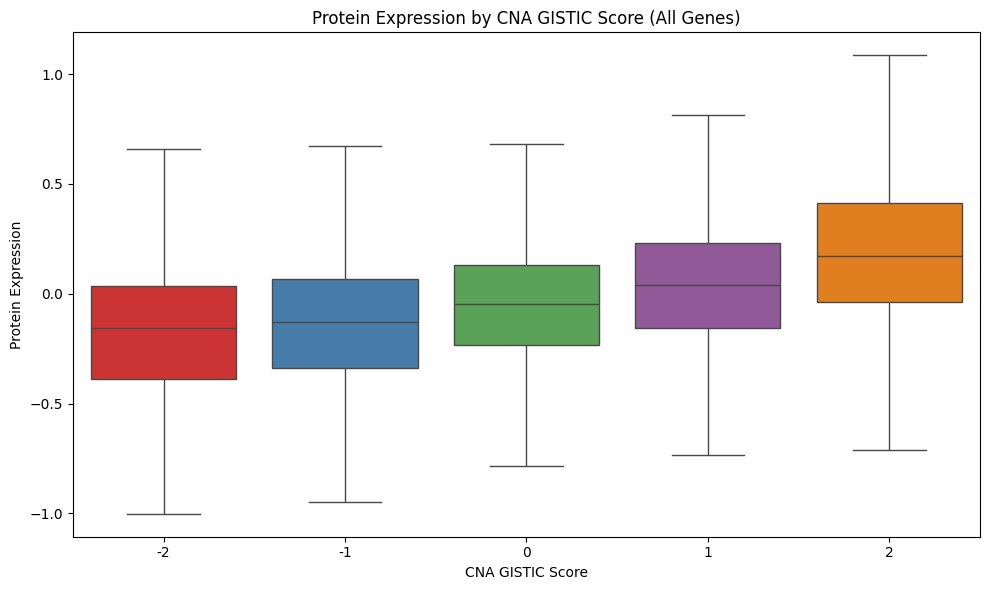

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x="CNA", 
            y="Protein",
            legend=False,
            hue="CNA", 
            data=merged_df, 
            palette="Set1",
            showfliers=False)

plt.title("Protein Expression by CNA GISTIC Score (All Genes)")
plt.xlabel("CNA GISTIC Score")
plt.ylabel("Protein Expression")
plt.tight_layout()
plt.show()

#### Per Gene

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

output_dir = "../figures/per_gene_boxplots"
os.makedirs(output_dir, exist_ok=True)

for gene in merged_df["Gene"].unique():
    gene_df = merged_df[merged_df["Gene"] == gene]

    if gene_df["CNA"].nunique() < 2:
        continue

    try:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x="CNA", y="Protein", data=gene_df, palette="Set1", hue="CNA", showfliers=False)
        plt.title(f"Protein Expression vs CNA for {gene}")
        plt.xlabel("CNA GISTIC Score")
        plt.ylabel("Protein Expression")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{gene}.png")
        plt.close()
    except Exception as e:
        print(f"Error plotting gene {gene}: {e}")
        plt.close()

Error plotting gene 1663: local variable 'boxprops' referenced before assignment
Error plotting gene 5420: local variable 'boxprops' referenced before assignment
Error plotting gene 54858: local variable 'boxprops' referenced before assignment
Error plotting gene 54938: local variable 'boxprops' referenced before assignment
Error plotting gene 5585: local variable 'boxprops' referenced before assignment
Error plotting gene 60488: local variable 'boxprops' referenced before assignment
Error plotting gene 6280: local variable 'boxprops' referenced before assignment
Error plotting gene 726: local variable 'boxprops' referenced before assignment
Error plotting gene 9620: local variable 'boxprops' referenced before assignment


### 📊 Statistical Measures for CNA vs Protein Expression

| **Statistic**       | **What It Tells You**                                                         | **Why It's Useful in This Case**                                                                  |
| ------------------- | ----------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| **t-statistic**     | The standardised difference between two group means, accounting for variance. | Shows how strongly CNA = ±2 differs from CNA = 0 in protein expression. Larger = more separation. |
| **p-value**         | Probability the observed difference happened by chance.                       | Tells you if the difference is statistically significant (typically p < 0.05).                    |
| **Cohen's d**       | A standardised **effect size**: how big the difference is in practical terms. | Quantifies how meaningful the difference is, even when p-value is very small.                    |

--- 

* **p-value** → Is the change significant?
* **t-statistic** → How strong is the separation?
* **Cohen’s d** → Is the difference biologically meaningful?

#### All Genes

In [166]:
from scipy.stats import ttest_ind

# Make sure CNA is int
merged_df = merged_df.dropna(subset=["CNA", "Protein"])
merged_df = merged_df.copy()  # create a copy to avoid chained assignment

# Avoid chained assignment: using multiple indexers like df[...][...] = ... can cause unintended behaviour,
# as it may modify a temporary copy rather than the original DataFrame.
# To prevent this, use .loc[] for safe in-place editing or .copy() if you need an independent slice.

merged_df["CNA"] = merged_df["CNA"].astype(int)

# Subsets
group_0 = merged_df[merged_df["CNA"] == 0]["Protein"]
group_amp = merged_df[merged_df["CNA"] == 2]["Protein"]
group_del = merged_df[merged_df["CNA"] == -2]["Protein"]

# T-tests
t_stat_amp, p_val_amp = ttest_ind(group_amp, group_0, equal_var=False)
t_stat_del, p_val_del = ttest_ind(group_del, group_0, equal_var=False)

print(f"CNA +2 vs 0 → t = {t_stat_amp:.3f}, p = {p_val_amp:.3e}")
print(f"CNA -2 vs 0 → t = {t_stat_del:.3f}, p = {p_val_del:.3e}")

CNA +2 vs 0 → t = 54.169, p = 0.000e+00
CNA -2 vs 0 → t = -9.968, p = 1.959e-22


### 📊 T-Test Results Interpretation

| Comparison  | t-statistic | p-value       | Interpretation                                                                         |
| ----------- | ----------- | ------------- | -------------------------------------------------------------------------------------- |
| **+2 vs 0** | 54.169      | 0             | Strong evidence that amplification is associated with **increased** protein expression |
| **−2 vs 0** | -9.968      | 1.959e-22     | Moderately strong evidence that deep deletion is associated with **decreased** protein expression |


### 📐 **Cohen’s d (Effect Size) Formula**

Cohen’s *d* measures the **standardised difference between two means**:

$$
d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}
$$

Where:

* $\bar{x}_1$, $\bar{x}_2$ = means of group 1 and group 2
* $s_p$ = pooled standard deviation:

$$
s_p = \sqrt{\frac{(n_1 - 1) s_1^2 + (n_2 - 1) s_2^2}{n_1 + n_2 - 2}}
$$

* $s_1$, $s_2$ = standard deviations of group 1 and group 2
* $n_1$, $n_2$ = sample sizes of each group

In [167]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = ((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2)
    return (x.mean() - y.mean()) / pooled_std**0.5

d_amp = cohens_d(group_amp, group_0)
d_del = cohens_d(group_del, group_0)

print(f"Cohen's d (+2 vs 0): {d_amp:.3f}")
print(f"Cohen's d (-2 vs 0): {d_del:.3f}")

Cohen's d (+2 vs 0): 0.639
Cohen's d (-2 vs 0): -0.313


### 📊 **Cohen’s d Effect Size Thresholds**
https://www.sciencedirect.com/science/article/abs/pii/S0191886916308194?via%3Dihub

| **Cohen’s *d*** | **Effect Size** | **Interpretation**                                  |
| --------------- | --------------- | --------------------------------------------------- |
| **0.0 – 0.19**  | Very small      | Almost no difference between groups                 |
| **0.2 – 0.49**  | Small           | Small, but possibly meaningful                      |
| **0.5 – 0.79**  | Medium          | Moderate difference, likely noticeable biologically |
| **0.8 – 1.19**  | Large           | Strong difference                                   |
| **1.2 – 1.99**  | Very large      | Very strong, highly meaningful                      |
| **≥ 2.0**       | Huge            | Groups are almost completely distinct               |

---

### (CNA vs Protein Expression):

* **d ≈ 0.2–0.4** might be statistically significant but not biologically meaningful.
* **d ≥ 0.5** is more compelling, it suggests CNAs meaningfully affect protein levels.
* **d ≥ 0.8** is a strong signal and worth reporting as a potential biomarker effect.

- The magnitude of |d| (absolute value) is what determines effect size strength
- The sign gives you direction

### 📊 **Cohen’s d Results Interpretation**

| Comparison  | Cohen’s *d* | Effect Size | Interpretation                                                              |
| ----------- | ----------- | ----------- | --------------------------------------------------------------------------- |
| **+2 vs 0** | **0.639**   | Medium      | Amplification is associated with **higher** protein expression, as expected |
| **-2 vs 0** | **-0.313**  | Small      | Deep deletion is associated with **lower** protein expression, as expected  |


#### Per Gene (t-test + Cohen's D)

In [177]:
merged_df = pd.read_csv("../results/cnv_prot_boxplot.csv")

In [178]:
print(merged_df.columns)
print(merged_df.head())

Index(['Unnamed: 0', 'Gene', 'Sample', 'CNA', 'Protein'], dtype='object')
   Unnamed: 0   Gene           Sample CNA Protein
0           0  10000  TCGA-13-1409-01   2   0.969
1           1  10000  TCGA-13-1410-01   1  0.0311
2           2  10000  TCGA-13-1487-01   1  0.0831
3           3  10000  TCGA-13-1488-01   1  0.4446
4           4  10000  TCGA-13-1494-01   0  0.3586


In [179]:
# Clean CNA column: remove whitespace/newlines, convert to int
merged_df["CNA"] = merged_df["CNA"].astype(str).str.strip()  # remove whitespace

merged_df = merged_df[merged_df["CNA"].str.match(r"^-?\d+$")]  # keep only integer-like strings
# ^     → Asserts the start of the string
# -?    → Matches an optional minus sign (zero or one occurrence of '-')
# \d+   → Matches one or more digits (0–9)
# $     → Asserts the end of the string

# This ensures the entire string consists of digits only, with an optional leading minus sign.
# Examples matched: "0", "42", "-7"
# Examples not matched: "12.5", "abc", "3-2"

merged_df["CNA"] = merged_df["CNA"].astype(int)

# Convert Protein to numeric, coerce errors to NaN and drop them
merged_df["Protein"] = pd.to_numeric(merged_df["Protein"], errors="coerce")
merged_df = merged_df.dropna(subset=["Protein"])

print(merged_df["CNA"].value_counts())

CNA
 1    50472
 0    38742
-1    18864
 2    10768
-2     1010
Name: count, dtype: int64


In [180]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Load data
merged_df = pd.read_csv("../results/cnv_prot_boxplot.csv")

# Clean CNA column: remove whitespace/newlines, keep integer-like strings, convert to int
merged_df["CNA"] = merged_df["CNA"].astype(str).str.strip()
merged_df = merged_df[merged_df["CNA"].str.match(r"^-?\d+$")]
merged_df["CNA"] = merged_df["CNA"].astype(int)

# Convert Protein to numeric and drop NaNs
merged_df["Protein"] = pd.to_numeric(merged_df["Protein"], errors="coerce")
merged_df = merged_df.dropna(subset=["Protein"])

# Define Cohen's d function with sample size check
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = ((nx - 1)*x.std(ddof=1)**2 + (ny - 1)*y.std(ddof=1)**2) / (nx + ny - 2)
    if pooled_std <= 0:
        return np.nan
    return (x.mean() - y.mean()) / np.sqrt(pooled_std)

results = []

for gene in merged_df["Gene"].unique():
    gene_df = merged_df[merged_df["Gene"] == gene].dropna(subset=["CNA", "Protein"])

    # Extract groups
    group_0 = gene_df[gene_df["CNA"] == 0]["Protein"]
    group_amp = gene_df[gene_df["CNA"] == 2]["Protein"]
    group_del = gene_df[gene_df["CNA"] == -2]["Protein"]

    # Require at least 3 samples per comparison group
    if len(group_0) < 3:
        continue

    # Amplification vs neutral
    if len(group_amp) >= 3:
        t_amp, p_amp = ttest_ind(group_amp, group_0, equal_var=False)
        d_amp = cohens_d(group_amp, group_0)
    else:
        t_amp, p_amp, d_amp = np.nan, np.nan, np.nan

    # Deletion vs neutral
    if len(group_del) >= 3:
        t_del, p_del = ttest_ind(group_del, group_0, equal_var=False)
        d_del = cohens_d(group_del, group_0)
    else:
        t_del, p_del, d_del = np.nan, np.nan, np.nan

    results.append({
        "Gene": gene,
        "T-statistic (Amplification vs Neutral)": t_amp,
        "P-value (Amplification vs Neutral)": p_amp,
        "Cohen's d (Amplification vs Neutral)": d_amp,
        "T-statistic (Deletion vs Neutral)": t_del,
        "P-value (Deletion vs Neutral)": p_del,
        "Cohen's d (Deletion vs Neutral)": d_del
    })

# Save results
gene_stats_df = pd.DataFrame(results)
gene_stats_df.to_csv("../results/per_gene_stats_all.csv", index=False)

print("Analysis complete.")

Analysis complete.


In [181]:
gene_stats_df.shape

(1099, 7)

In [182]:
import pandas as pd

# Load per-gene stats
stats_df = pd.read_csv("../results/per_gene_stats_all.csv")

# Filter out genes where ALL 6 stats are NaN
filtered_df = stats_df.dropna(
    subset=[
        "T-statistic (Amplification vs Neutral)",
        "P-value (Amplification vs Neutral)",
        "Cohen's d (Amplification vs Neutral)",
        "T-statistic (Deletion vs Neutral)",
        "P-value (Deletion vs Neutral)",
        "Cohen's d (Deletion vs Neutral)"
    ],
    how="all"
)

# Save filtered result
filtered_df.to_csv("../results/per_gene_stats_filtered.csv", index=False)

In [183]:
filtered_df.shape

(1067, 7)

In [191]:
# Load filtered results
filtered_df = pd.read_csv("../results/per_gene_stats_filtered.csv")

# Count significantly amplified genes
amp_genes = filtered_df[
    (filtered_df["P-value (Amplification vs Neutral)"] < 0.05) &
    (filtered_df["Cohen's d (Amplification vs Neutral)"] > 0)
]

# Count significantly deleted genes
del_genes = filtered_df[
    (filtered_df["P-value (Deletion vs Neutral)"] < 0.05) &
    (filtered_df["Cohen's d (Deletion vs Neutral)"] < 0)
]

print(f"Significant amplified genes: {len(amp_genes)}")
print(f"Significant deleted genes: {len(del_genes)}")


Significant amplified genes: 470
Significant deleted genes: 46


### Linear Regression

In [187]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load and clean data as before
merged_df = pd.read_csv("../results/cnv_prot_boxplot.csv")

# Clean CNA column
merged_df["CNA"] = merged_df["CNA"].astype(str).str.strip()
merged_df = merged_df[merged_df["CNA"].str.match(r"^-?\d+$")]
merged_df["CNA"] = merged_df["CNA"].astype(int)

# Convert Protein to numeric
merged_df["Protein"] = pd.to_numeric(merged_df["Protein"], errors="coerce")
merged_df = merged_df.dropna(subset=["Protein"])

results = []

for gene in merged_df["Gene"].unique():
    gene_df = merged_df[merged_df["Gene"] == gene].dropna(subset=["CNA", "Protein"])
    
    # Require minimum samples (e.g., at least 6 to fit regression)
    if len(gene_df) < 6:
        continue
    
    X = gene_df["CNA"]
    y = gene_df["Protein"]
    
    # Add intercept term
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    coef = model.params["CNA"]
    pval = model.pvalues["CNA"]
    
    results.append({
        "Gene": gene,
        "Regression Coefficient (Effect Size)": coef,
        "P-value": pval,
        "Sample Size": len(gene_df),
        "R-squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df.to_csv("../results/per_gene_linear_regression.csv", index=False)

print("Linear regression analysis complete.")

Linear regression analysis complete.


### Significant Genes

In [200]:
import pandas as pd

# Load the linear regression results
stats_df = pd.read_csv("../results/per_gene_linear_regression.csv")

# Significant amplification genes (positive effect size with p < 0.05)
linear_regression_sig_genes = stats_df[(stats_df["P-value"] < 0.05)][["Gene", "Regression Coefficient (Effect Size)", "P-value", "Sample Size", "R-squared"]]

linear_regression_sig_genes.to_csv("../results/linear_regression_significant_genes.csv", index=False)

In [199]:
linear_regression_sig_genes.shape

(737, 5)